# Heart Disease Prediction 🫀
EDA + KNN Classifier on the Cleveland Heart Disease Dataset

In [22]:
import os
# ✅ Fix: suppress joblib wmic warning on Windows Python 3.14
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np

## 1. Load Data

In [ ]:
# ✅ Fix: relative path instead of hardcoded absolute path
df = pd.read_csv('heart_disease_data.csv')

numerical   = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical = ['genre', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']

df.head()

,age,genre,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Data Quality Checks

In [24]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Duplicate Rows ===')
duplicates = df[df.duplicated()]
if not duplicates.empty:
    print(f'{len(duplicates)} duplicate rows found:')
    print(duplicates)
else:
    print('No duplicate rows found.')

print('\n=== Outliers (IQR method) ===')
for col in numerical:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col}: {n_out} outliers')

=== Missing Values ===
age         0
genre       0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== Duplicate Rows ===
1 duplicate rows found:
     age  genre  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
164   38      1   2       138   175    0        1      173      0      0.0   

     slope  ca  thal  target  
164      2   4     2       1  

=== Outliers (IQR method) ===
  age: 0 outliers
  trestbps: 9 outliers
  chol: 5 outliers
  thalach: 1 outliers
  oldpeak: 5 outliers
  ca: 25 outliers


## 3. Descriptive Statistics

In [25]:
df.describe()

,age,genre,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 4. Numerical Features — Histograms, Boxplots, Q-Q Plots

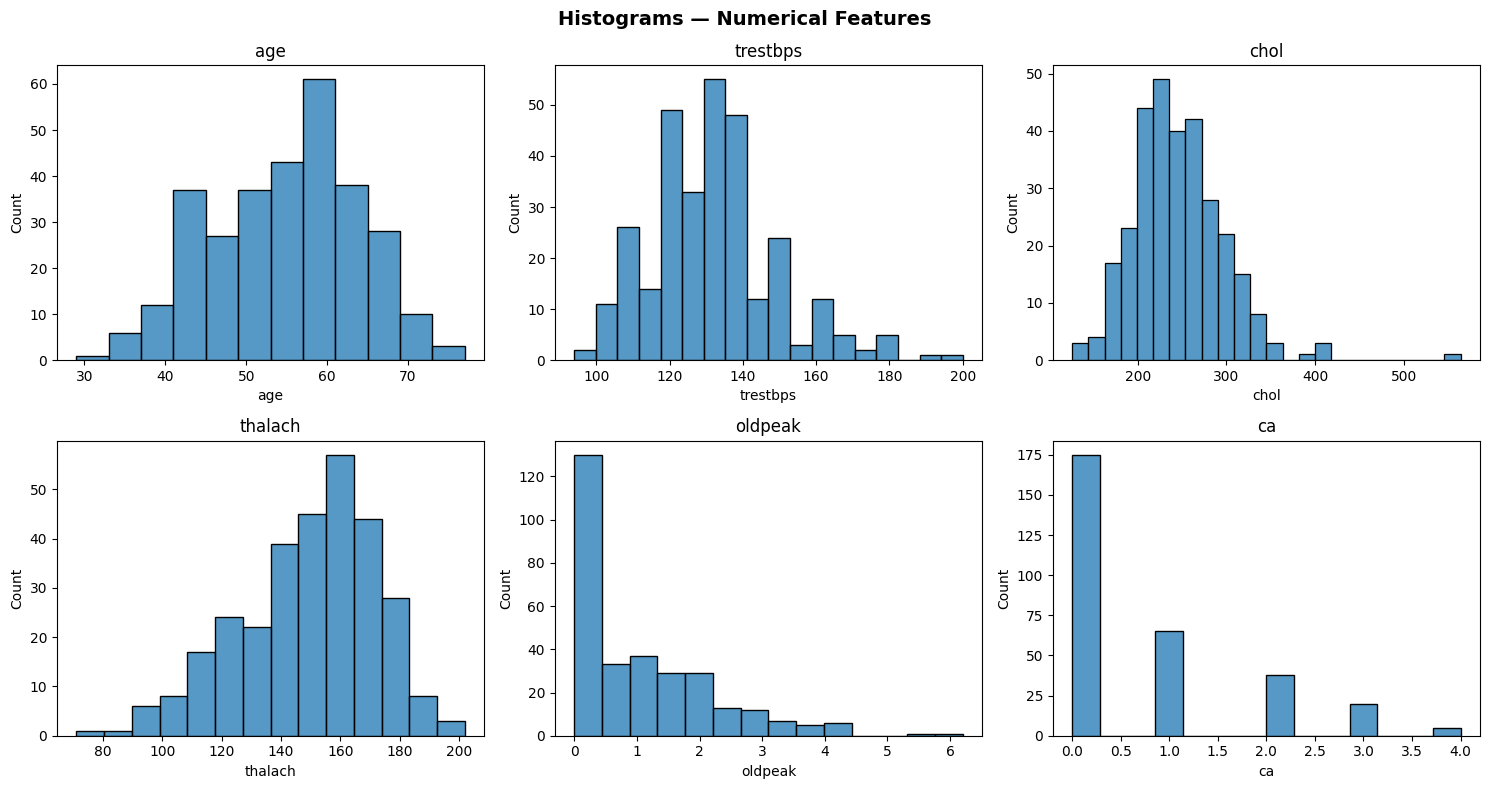

In [26]:
# ── Histograms ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Histograms — Numerical Features', fontsize=14, fontweight='bold')
for ax, col in zip(axes.flatten(), numerical):
    sns.histplot(data=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

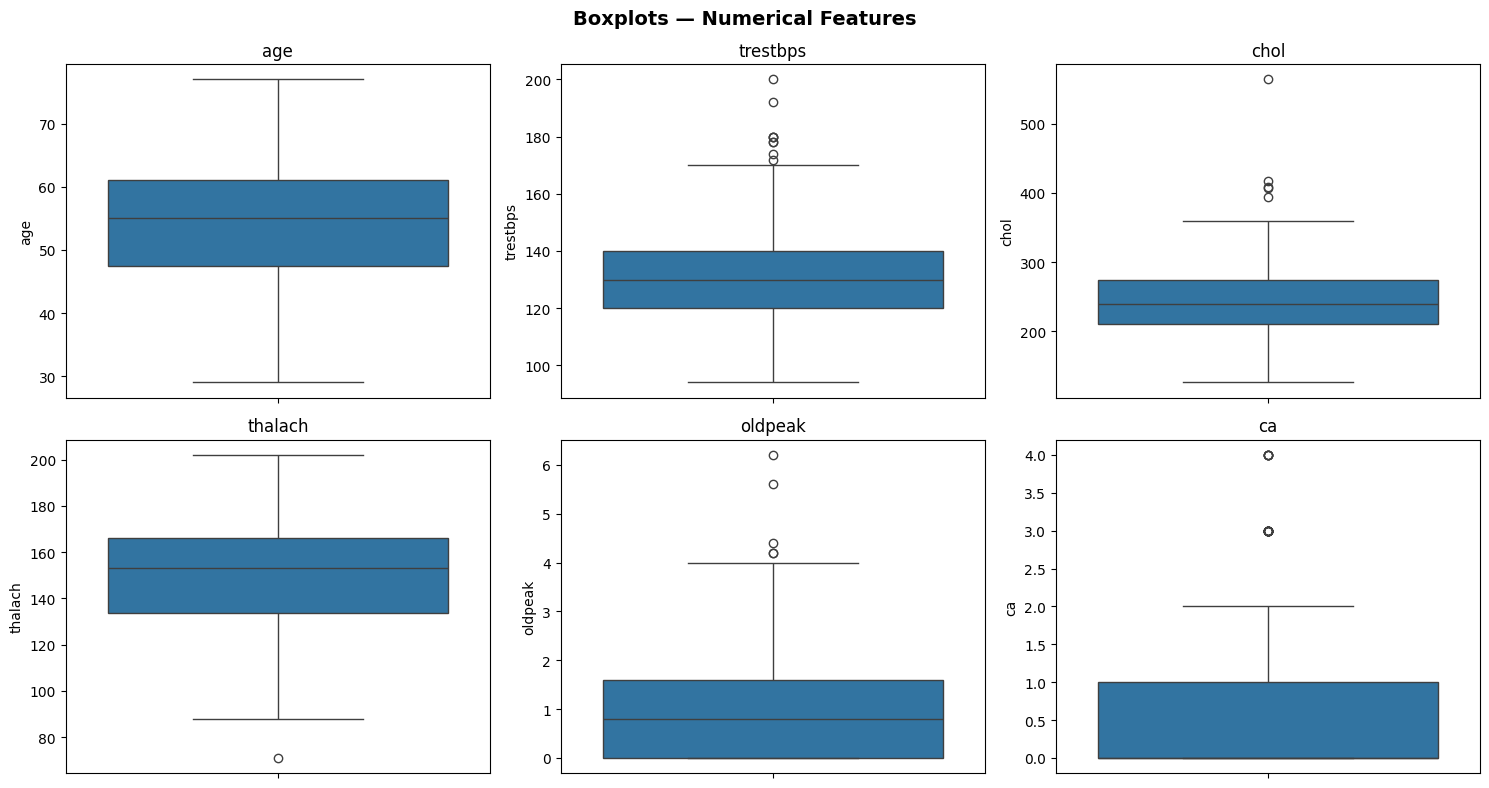

In [27]:
# ── Boxplots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Boxplots — Numerical Features', fontsize=14, fontweight='bold')
for ax, col in zip(axes.flatten(), numerical):
    sns.boxplot(data=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

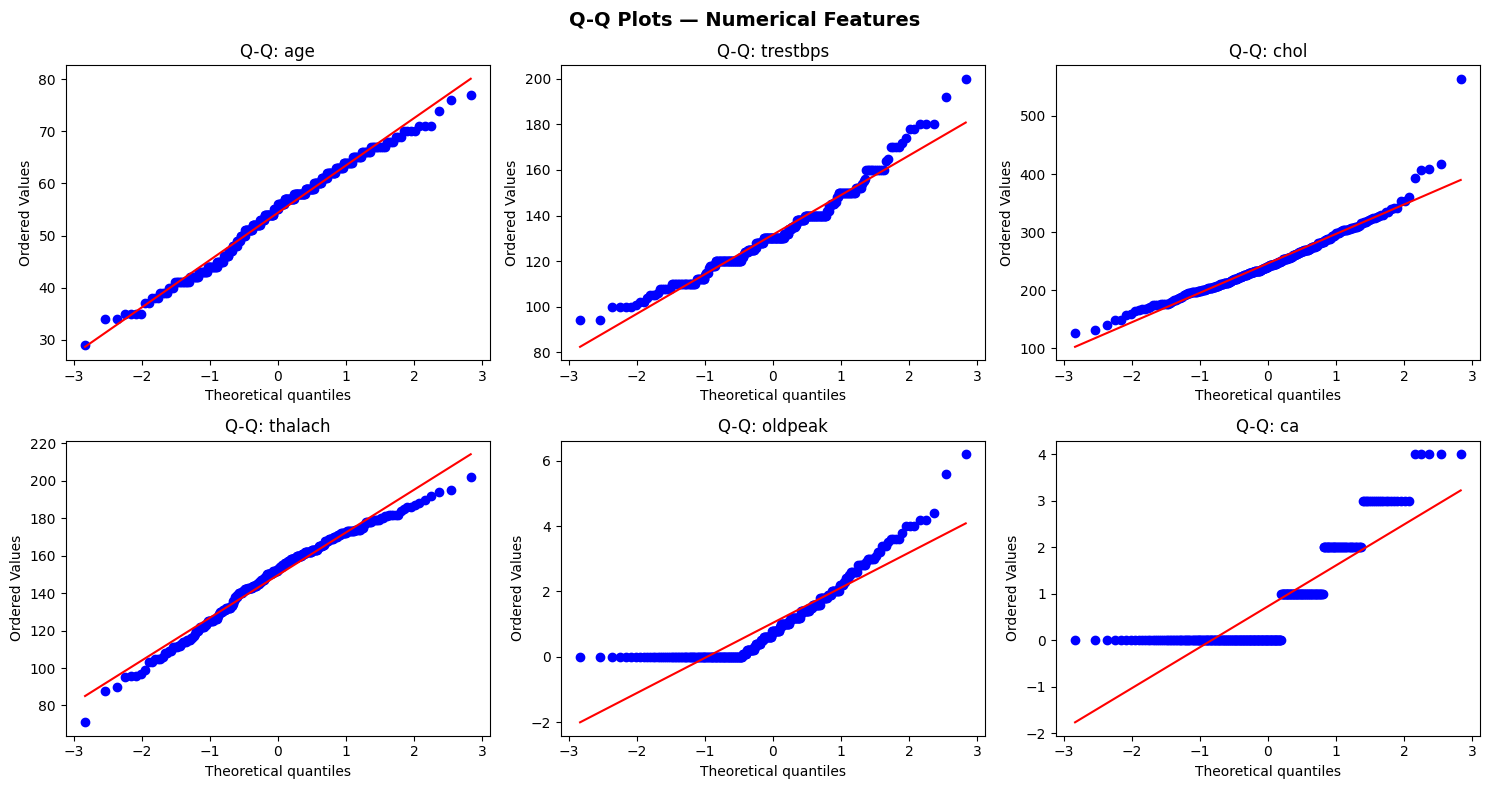

In [28]:
# ── Q-Q Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Q-Q Plots — Numerical Features', fontsize=14, fontweight='bold')
for ax, col in zip(axes.flatten(), numerical):
    stats.probplot(df[col], dist='norm', plot=ax)
    ax.set_title(f'Q-Q: {col}')
plt.tight_layout()
plt.show()

## 5. Categorical Features — Count Plots & Pie Charts

In [29]:
# ✅ Fix 1: genre was swapped — Cleveland dataset: 0=Female, 1=Male
#           (the count plot showed 206 labeled as 'Female', but 206 are male in the dataset)
# ✅ Fix 2: thal was missing key 3 → caused 117 NaN after .map()
#           UCI encoding: 1=Normal, 2=Fixed Defect, 3=Reversible Defect; 0=Unknown/missing
mappings = {
    'genre':   {0: 'Female', 1: 'Male'},
    'cp':      {0: 'Asymptomatic', 1: 'Non-Anginal Pain', 2: 'Atypical Angina', 3: 'Typical Angina'},
    'fbs':     {0: 'No', 1: 'Yes'},
    'restecg': {0: 'Normal', 1: 'ST-T Wave Abnormality', 2: 'Left Ventricular Hypertrophy'},
    'exang':   {0: 'No', 1: 'Yes'},
    'slope':   {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
    'ca':      {0: '0 Vessels', 1: '1 Vessel', 2: '2 Vessels', 3: '3 Vessels'},
    'thal':    {0: 'Unknown', 1: 'Normal', 2: 'Fixed Defect', 3: 'Reversible Defect'},
    'target':  {0: 'No Heart Disease', 1: 'Heart Disease'}
}

for col in categorical:
    df[col] = df[col].map(mappings[col])

# Should print all zeros now
print('NaN after mapping:')
print(df[categorical].isnull().sum())

NaN after mapping:
genre      0
cp         0
fbs        0
restecg    0
exang      0
slope      0
thal       0
target     0
dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_3712\3999842413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2', ax=ax)
C:\Users\hp\AppData\Local\Temp\ipykernel_3712\3999842413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2', ax=ax)
C:\Users\hp\AppData\Local\Temp\ipykernel_3712\3999842413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2', ax=ax)
C:\Users\hp\AppData\Local\Temp\ipykernel_3712\3999842413.py:7: FutureWarning: 

Passing `palette` without assign

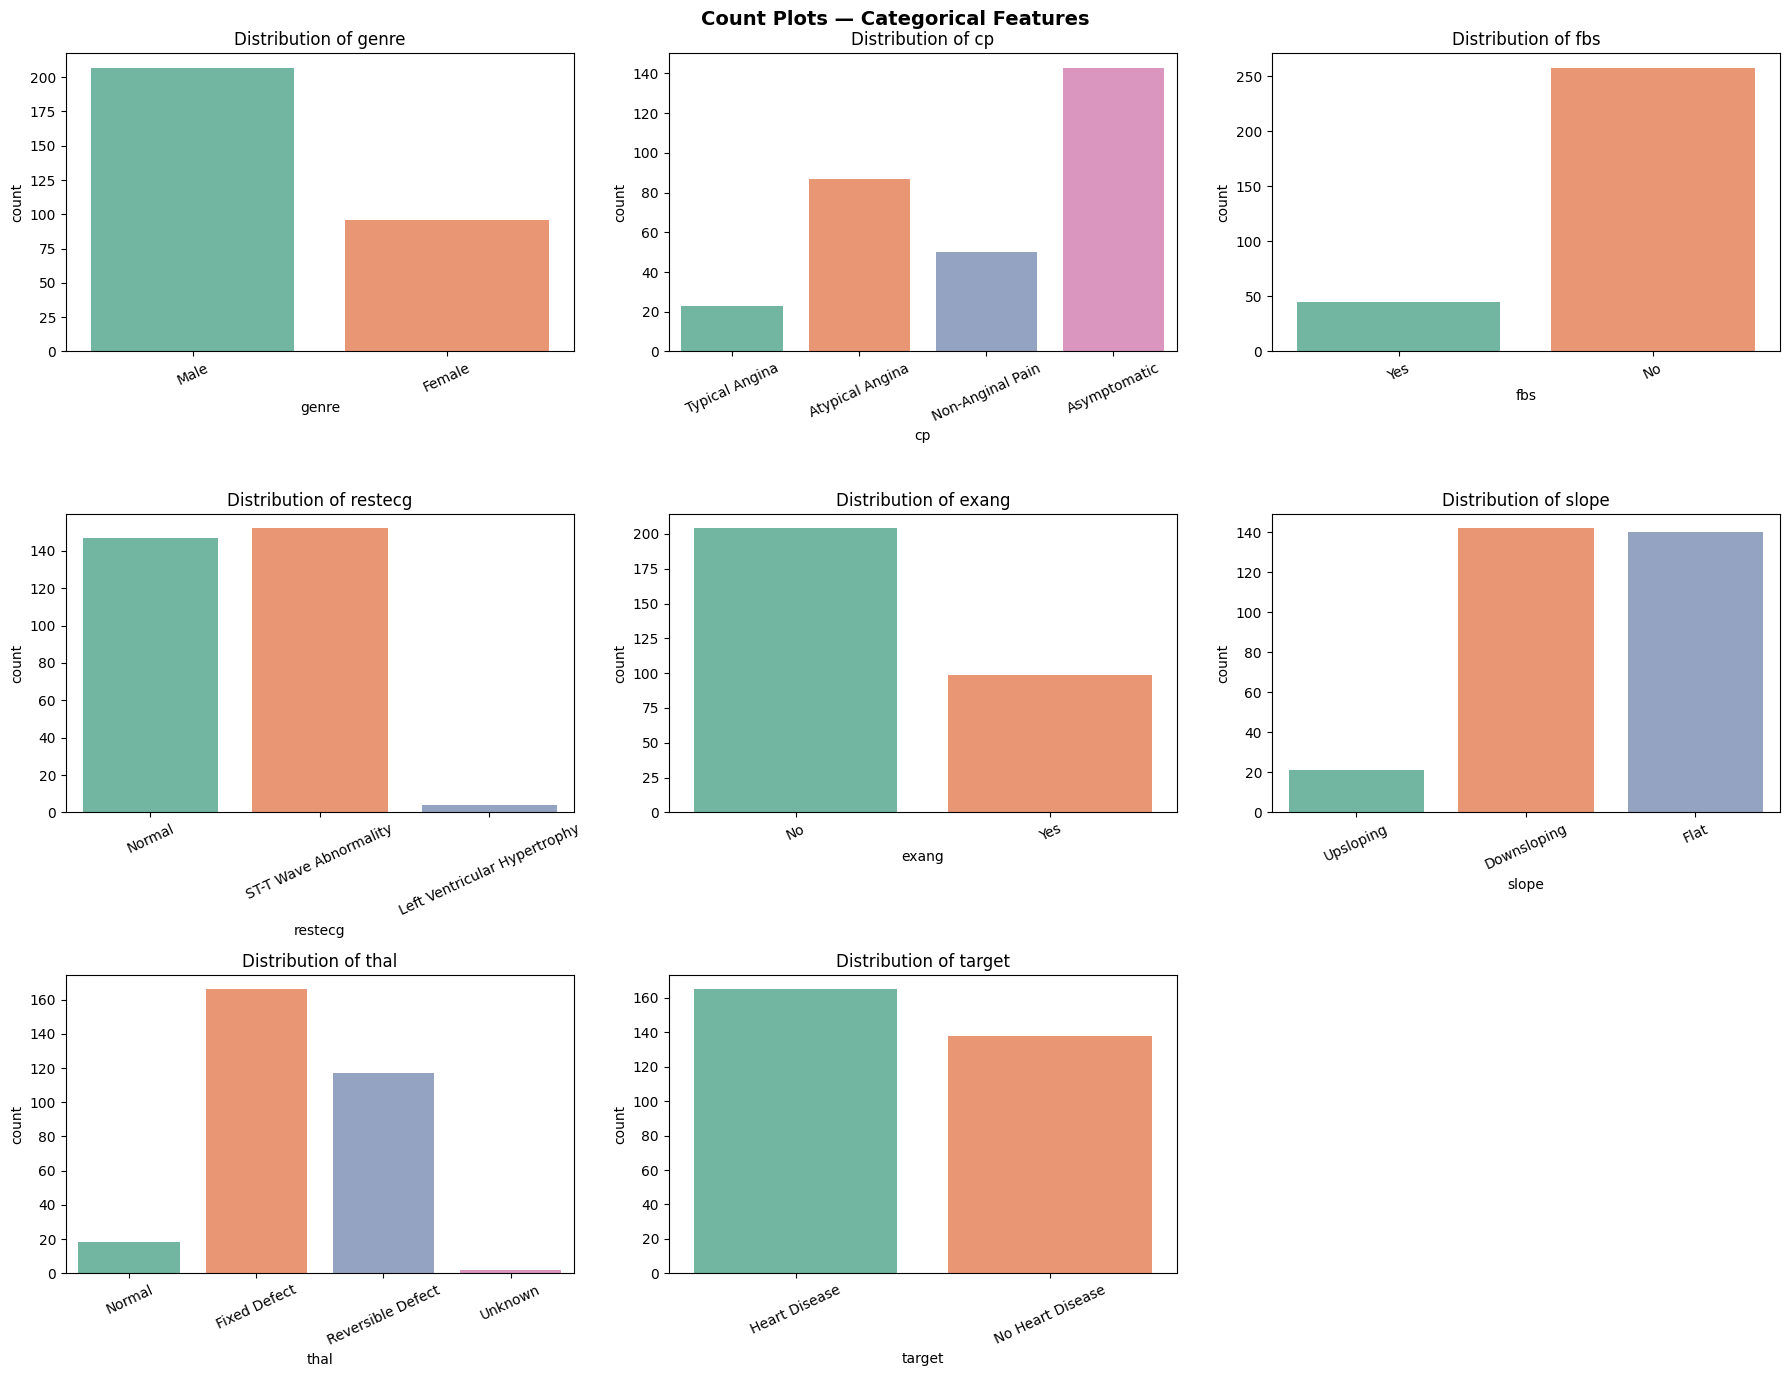

In [30]:
# ── Count Plots ───────────────────────────────────────────────────────────
# ✅ Fix: 8 columns but 3×3=9 axes → hide the empty 9th subplot
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Count Plots — Categorical Features', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()
for ax, col in zip(axes_flat, categorical):
    sns.countplot(x=df[col], palette='Set2', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=25)
axes_flat[len(categorical)].set_visible(False)  # hide unused 9th cell
plt.tight_layout()
plt.show()

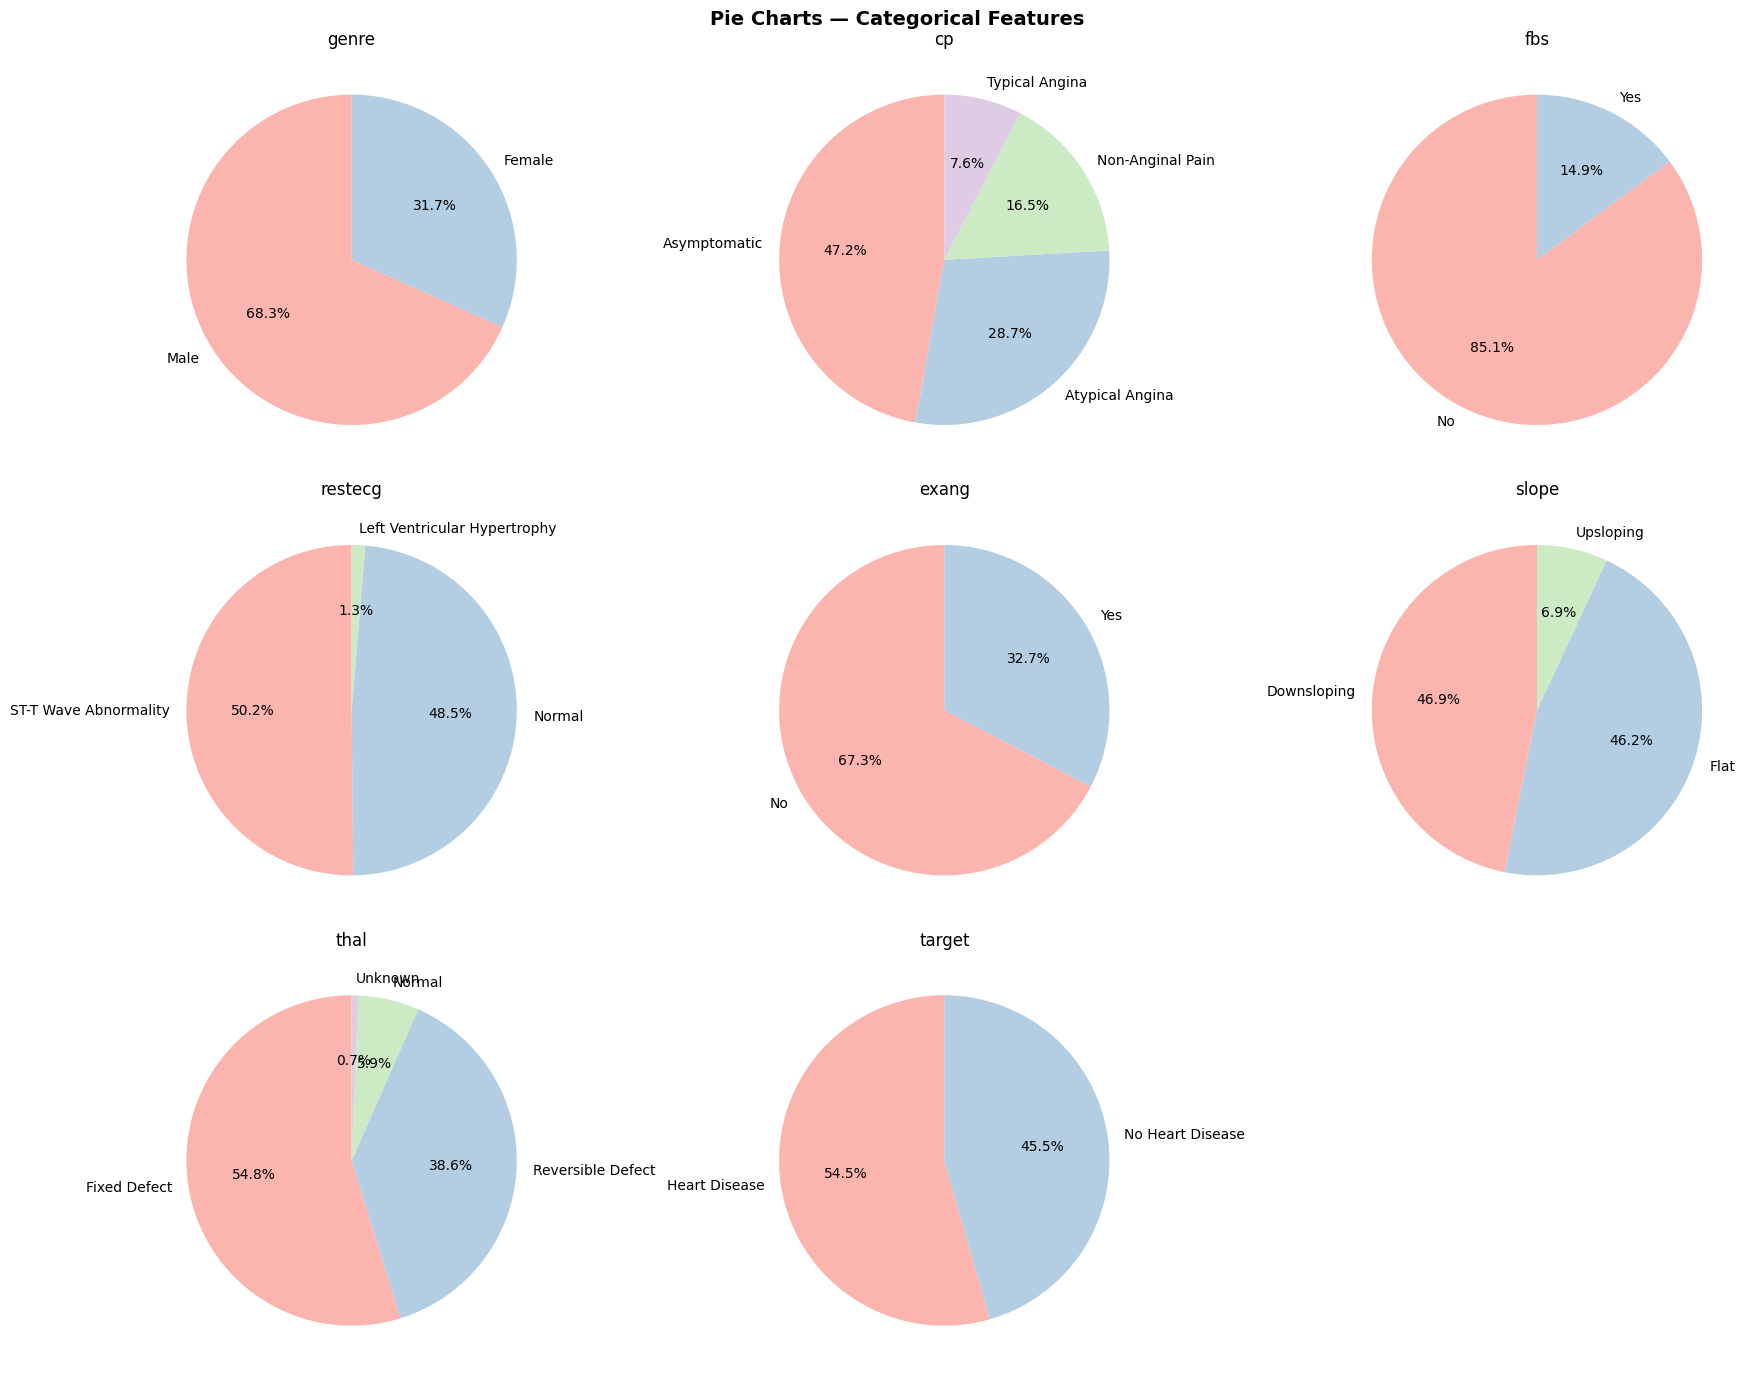

In [31]:
# ── Pie Charts ────────────────────────────────────────────────────────────
# ✅ Fix: same — hide the empty 9th subplot
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Pie Charts — Categorical Features', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()
for ax, col in zip(axes_flat, categorical):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90,
           colors=plt.cm.Pastel1.colors[:len(counts)])
    ax.set_title(col)
axes_flat[len(categorical)].set_visible(False)  # hide unused 9th cell
plt.tight_layout()
plt.show()

## 6. Bivariate Analysis

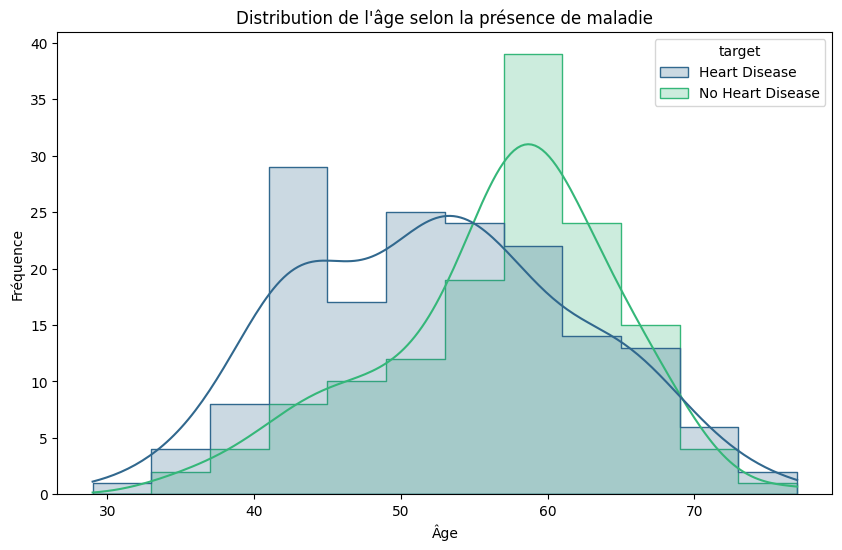

In [32]:
# Age distribution by target
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', kde=True, element='step', palette='viridis')
plt.title("Distribution de l'âge selon la présence de maladie")
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.show()

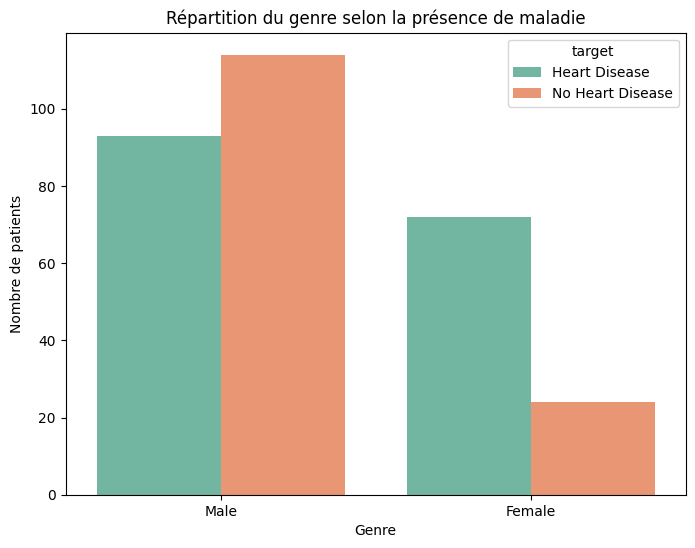

In [33]:
# Genre by target
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='genre', hue='target', palette='Set2')
plt.title('Répartition du genre selon la présence de maladie')
plt.xlabel('Genre')
plt.ylabel('Nombre de patients')
plt.show()

<Figure size 1200x800 with 0 Axes>

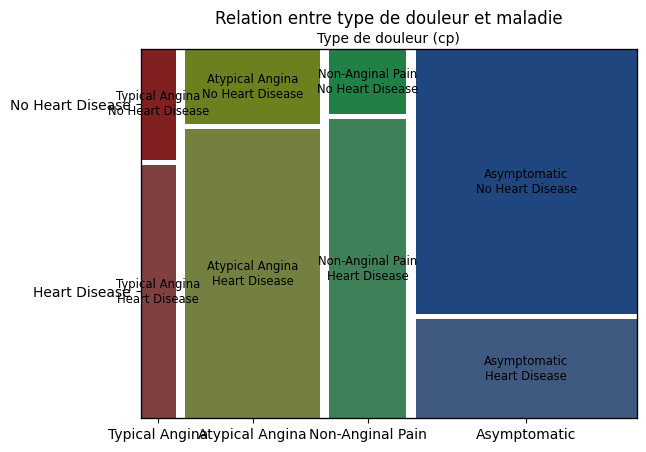

In [34]:
# Mosaic plot: cp × target
plt.figure(figsize=(12, 8))
mosaic(df, ['cp', 'target'], title='Relation entre type de douleur et maladie', gap=0.02)
plt.xlabel('Type de douleur (cp)')
plt.ylabel('Maladie (target)')
plt.show()

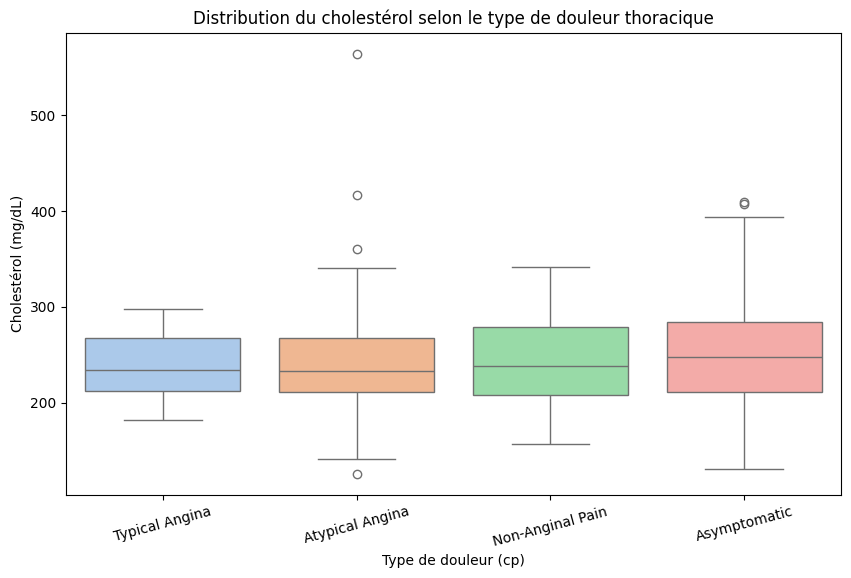

In [35]:
# Cholesterol by chest pain type
plt.figure(figsize=(10, 6))
# ✅ Fix: added hue='cp' and legend=False to suppress seaborn palette deprecation warning
sns.boxplot(data=df, x='cp', y='chol', hue='cp', palette='pastel', legend=False)
plt.title('Distribution du cholestérol selon le type de douleur thoracique')
plt.xlabel('Type de douleur (cp)')
plt.ylabel('Cholestérol (mg/dL)')
plt.xticks(rotation=15)
plt.show()

## 7. Correlation Analysis

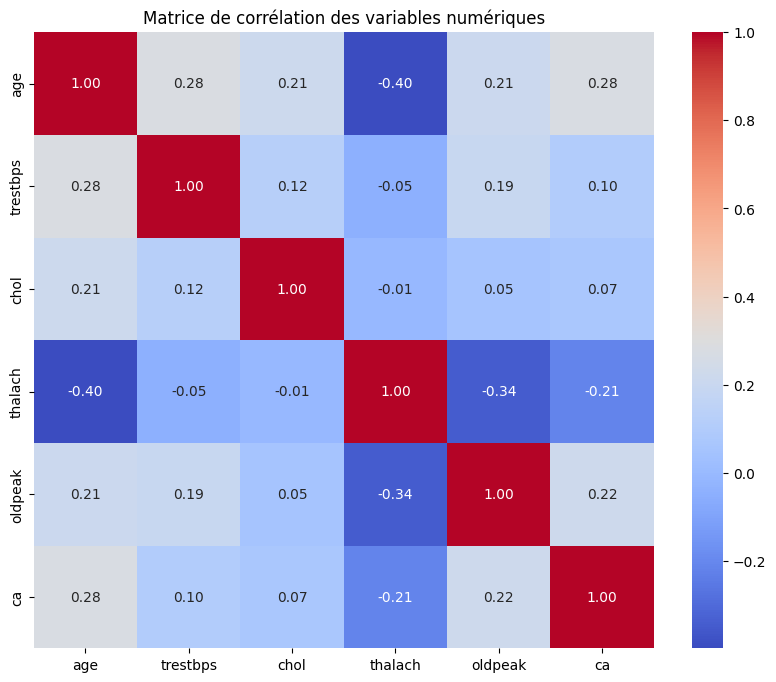

In [36]:
correlation_matrix = df[numerical].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation des variables numériques')
plt.show()

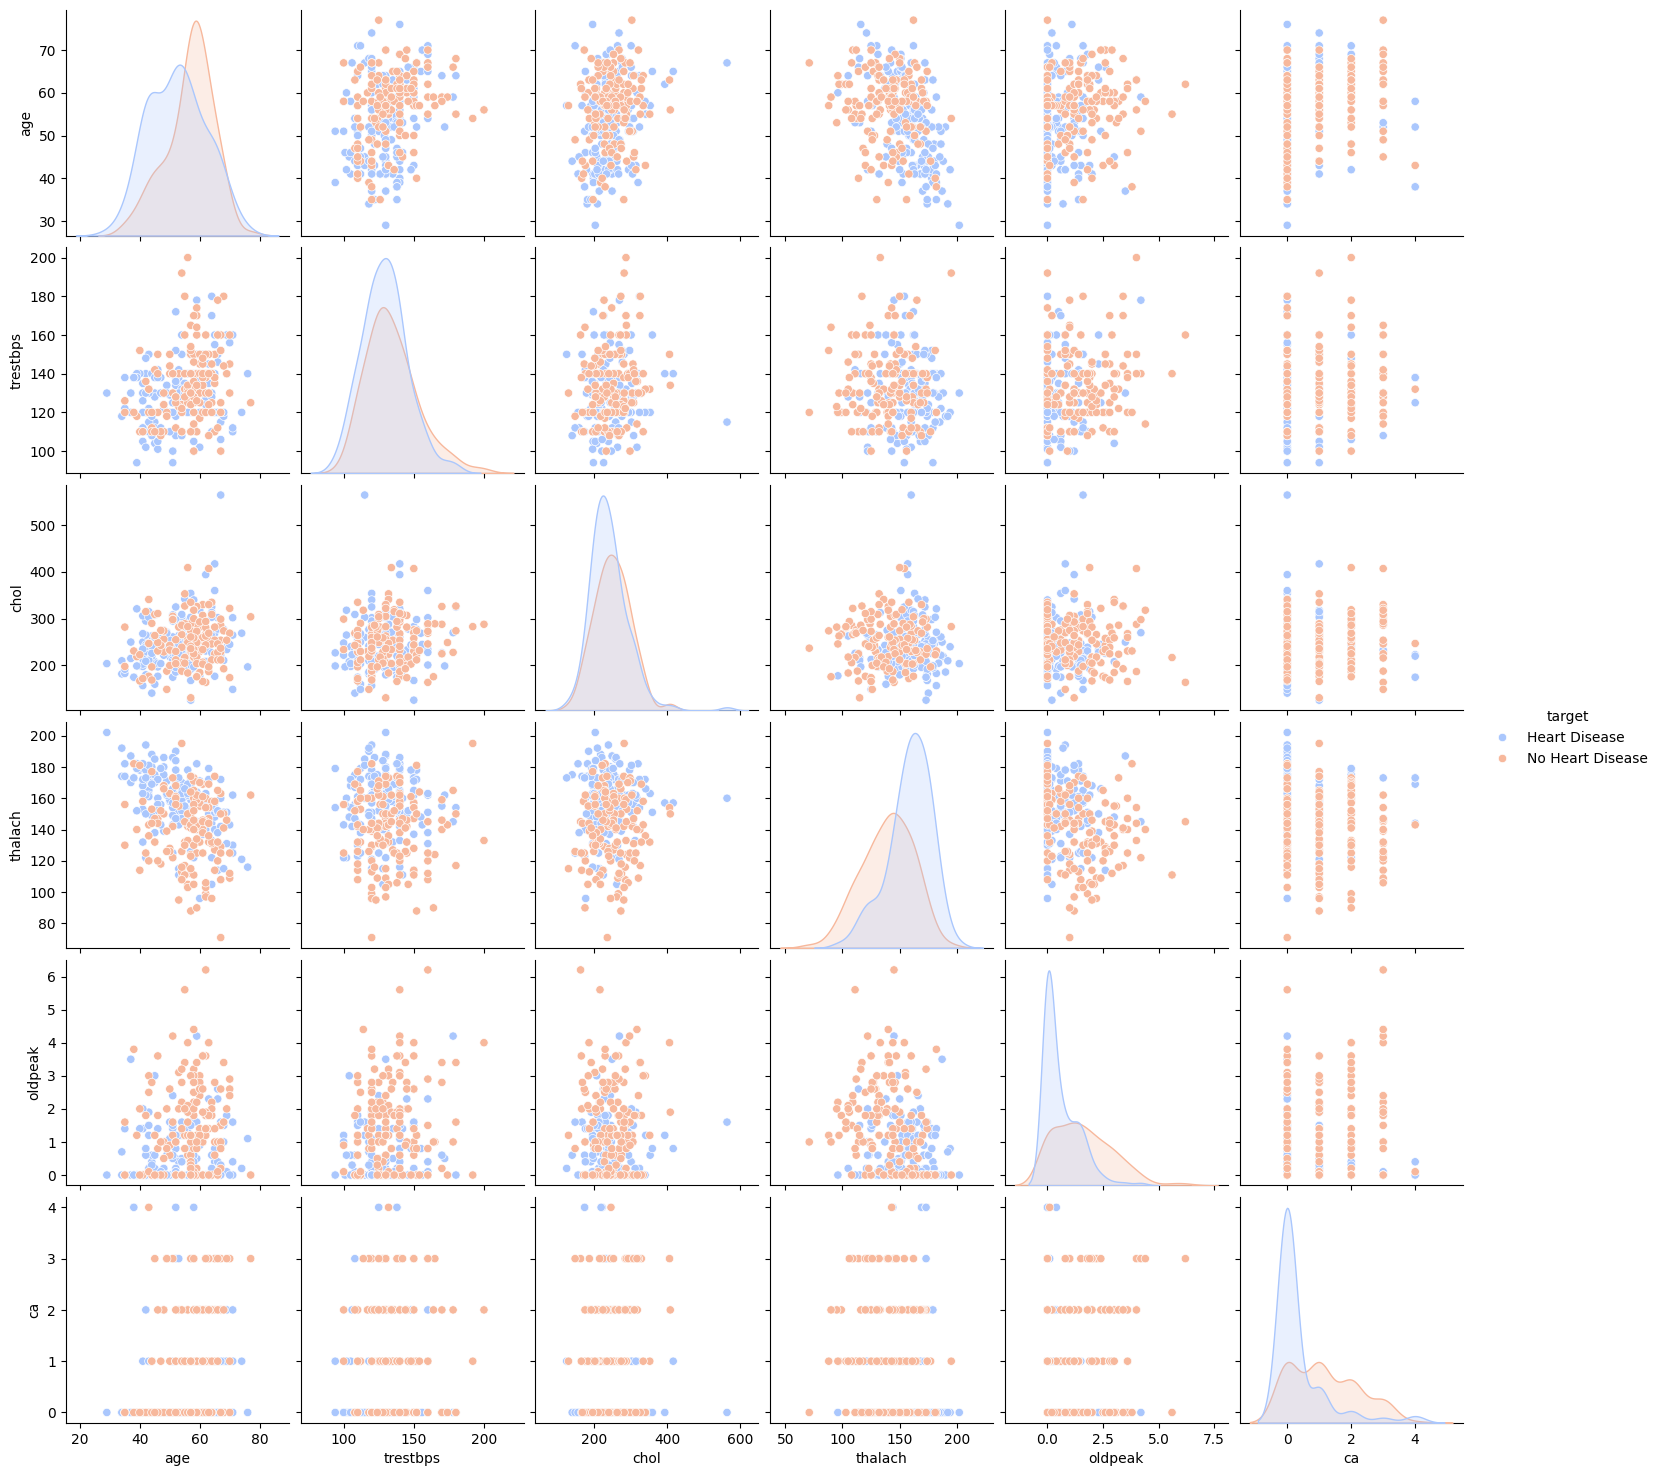

In [37]:
sns.pairplot(df, vars=numerical, hue='target', palette='coolwarm', diag_kind='kde')
plt.show()

## 8. KNN Modeling

In [38]:
# Re-encode for sklearn (strings → numbers via one-hot encoding)
X = df.drop(columns=['target'])
y = df['target']
X = pd.get_dummies(X, drop_first=True)
X = X.dropna()
y = y[X.index]

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Feature matrix shape: (303, 19)
Target distribution:
target
Heart Disease       165
No Heart Disease    138
Name: count, dtype: int64


In [39]:
# ✅ Fix: apply StandardScaler before KNN
# KNN uses Euclidean distance — without scaling, chol (120–560) completely
# dominates binary features like fbs (0/1), making the model near-random
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print('Feature ranges BEFORE scaling (sample):')
print(X[['age', 'chol', 'thalach']].agg(['min', 'max']))
print('\nFeature ranges AFTER scaling (should be ~[-3, 3]):')
print(X_scaled[['age', 'chol', 'thalach']].agg(['min', 'max']).round(2))

Feature ranges BEFORE scaling (sample):
     age  chol  thalach
min   29   126       71
max   77   564      202

Feature ranges AFTER scaling (should be ~[-3, 3]):
     age  chol  thalach
min -2.8 -2.32    -3.44
max  2.5  6.14     2.29


In [40]:
# Custom train/test split
def custom_train_test_split(X, y, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)
    indices   = np.random.permutation(len(X))
    n_test    = int(len(X) * test_size)
    test_idx  = indices[:n_test]
    train_idx = indices[n_test:]
    return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]

X_train, X_test, y_train, y_test = custom_train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 243 | Test: 60


In [41]:
# KNN k=1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
acc = accuracy_score(y_test, knn.predict(X_test))
print(f'Accuracy with k=1: {acc:.2f}')

Accuracy with k=1: 0.85


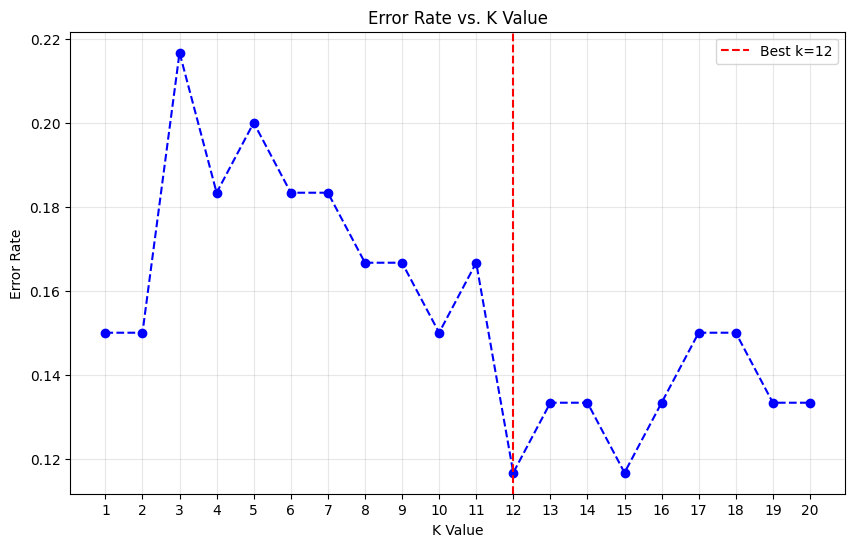

Best k: 12 | Error rate: 0.12 | Accuracy: 0.88


In [42]:
# Error rate vs K
k_values    = range(1, 21)
error_rates = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    error_rates.append(1 - accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rates, marker='o', linestyle='dashed', color='b')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Error Rate vs. K Value')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
best_k = k_values[np.argmin(error_rates)]
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.legend()
plt.show()

print(f'Best k: {best_k} | Error rate: {min(error_rates):.2f} | Accuracy: {1-min(error_rates):.2f}')